In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import statsmodels.api as sm
import sklearn

In [2]:
df = pd.read_csv('./full_data.csv')

In [3]:
df

,index,year,PICK,round,round_pick,TEAM,PLAYER,YEARS,TOTALS_G,TOTALS_MP,...,dcn_all_nba_votes_ma,pn_all_defense_votes_ma,dcn_all_defense_votes_ma,pn_all_rookie_votes_ma,dcn_all_rookie_votes_ma,rookie_first_ma,rookie_second_ma,dcn_past_retirement_ma,pn_past_retirement_ma,exists
0,0,1995,1,1,1,GSW,Joe Smith,16,1030.0,27022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,58,1996,1,1,1,PHI,Allen Iverson,14,914.0,37584.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,116,1997,1,1,1,SAS,Tim Duncan,19,1392.0,47368.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,173,1998,1,1,1,LAC,Michael Olowokandi,9,500.0,13129.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,231,1999,1,1,1,CHI,Elton Brand,17,1058.0,34910.0,...,0.758368,0.131835,0.370084,-0.651389,1.058809,0.8,0.2,1.0,0.8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1767,1357,2017,60,2,30,ATL,Alpha Kaba,0,NaN,NaN,...,0.000000,0.000000,0.000000,-0.141421,-0.178193,0.0,0.0,0.2,0.4,1
1768,1417,2018,60,2,30,PHI,Kostas Antetokounmpo,3,22.0,87.0,...,0.000000,0.000000,0.000000,-0.141421,-0.178193,0.0,0.0,0.2,0.6,1
1769,1477,2019,60,2,30,SAC,Vanja Marinković,0,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.2,0.4,1
1770,1537,2020,60,2,30,NOP,Sam Merrill,6,203.0,3581.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.4,0.6,1


In [4]:
df.columns

Index(['index', 'year', 'PICK', 'round', 'round_pick', 'TEAM', 'PLAYER',
       'YEARS', 'TOTALS_G', 'TOTALS_MP', 'final_season', 'ADVANCED_WS',
       'ADVANCED_WS/48', 'ADVANCED_BPM', 'ADVANCED_VORP', 'MVP_Votes',
       'First_MVP', 'RotY_Votes', 'RotY', 'DPOY_Votes', 'First_DPOY',
       'SMotY_Votes', 'First_SMotY', 'MIP_Votes', 'First_MIP', 'all_nba_votes',
       'all_defense_votes', 'all_rookie_votes', 'all_first', 'all_second',
       'all_third', 'all_races', 'def_first', 'def_second', 'mvp', 'rookie',
       'retired', 'rookie_first', 'rookie_second', 'dcn_past_retirement',
       'dcn_YEARS', 'dcn_TOTALS_G', 'dcn_TOTALS_MP', 'dcn_ADVANCED_WS',
       'dcn_ADVANCED_WS/48', 'dcn_MVP_Votes', 'dcn_RotY_Votes',
       'dcn_DPOY_Votes', 'dcn_SMotY_Votes', 'dcn_MIP_Votes',
       'dcn_all_nba_votes', 'dcn_all_defense_votes', 'dcn_all_rookie_votes',
       'pn_past_retirement', 'pn_YEARS', 'pn_TOTALS_G', 'pn_TOTALS_MP',
       'pn_ADVANCED_WS', 'pn_ADVANCED_WS/48', 'pn_MVP_Votes', 

In [9]:
df.fillna({'ADVANCED_WS': 0, 'ADVANCED_WS/48': 0, 'TOTALS_MP': 0, 'TOTALS_G': 0}, inplace=True)
df.retired = df.retired.astype(int)

In [12]:
feature_cols = [
        # 'PICK', 
    'retired', 'YEARS', 'exists', 'round', 'round_pick'
    ]
mms = sklearn.preprocessing.MinMaxScaler()

feature_df = df[feature_cols].copy()
feature_df = pd.DataFrame(mms.fit_transform(feature_df))
feature_df.columns = feature_cols
ws_model = sm.OLS(df['ADVANCED_WS'].copy().values, feature_df).fit()
ws48_model = sm.OLS(df['ADVANCED_WS/48'].copy().values, feature_df).fit()

In [13]:
print(ws_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.750
Model:                            OLS   Adj. R-squared (uncentered):              0.750
Method:                 Least Squares   F-statistic:                              1329.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:28:29   Log-Likelihood:                         -7406.6
No. Observations:                1772   AIC:                                  1.482e+04
Df Residuals:                    1768   BIC:                                  1.484e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [14]:
print(ws48_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.458
Model:                            OLS   Adj. R-squared (uncentered):              0.456
Method:                 Least Squares   F-statistic:                              373.0
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                   5.06e-233
Time:                        16:28:30   Log-Likelihood:                          2064.7
No. Observations:                1772   AIC:                                     -4121.
Df Residuals:                    1768   BIC:                                     -4099.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [15]:
feature_cols = [
        # 'PICK', 
    'retired', 'TOTALS_MP', 'exists', 'round', 'round_pick'
    ]
mms = sklearn.preprocessing.MinMaxScaler()

feature_df = df[feature_cols].copy()
feature_df = pd.DataFrame(mms.fit_transform(feature_df))
feature_df.columns = feature_cols
ws_model = sm.OLS(df['ADVANCED_WS'].copy().values, feature_df).fit()
ws48_model = sm.OLS(df['ADVANCED_WS/48'].copy().values, feature_df).fit()

In [16]:
print(ws_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.892
Model:                            OLS   Adj. R-squared (uncentered):              0.892
Method:                 Least Squares   F-statistic:                              3658.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:28:31   Log-Likelihood:                         -6662.9
No. Observations:                1772   AIC:                                  1.333e+04
Df Residuals:                    1768   BIC:                                  1.336e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [17]:
print(ws48_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.407
Model:                            OLS   Adj. R-squared (uncentered):              0.406
Method:                 Least Squares   F-statistic:                              303.5
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                   7.30e-199
Time:                        16:28:31   Log-Likelihood:                          1985.8
No. Observations:                1772   AIC:                                     -3964.
Df Residuals:                    1768   BIC:                                     -3942.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [18]:
feature_cols = [
        # 'PICK', 
    'retired', 'TOTALS_G', 'exists', 'round', 'round_pick'
    ]
mms = sklearn.preprocessing.MinMaxScaler()

feature_df = df[feature_cols].copy()
feature_df = pd.DataFrame(mms.fit_transform(feature_df))
feature_df.columns = feature_cols
ws_model = sm.OLS(df['ADVANCED_WS'].copy().values, feature_df).fit()
ws48_model = sm.OLS(df['ADVANCED_WS/48'].copy().values, feature_df).fit()

In [19]:
print(ws_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.808
Model:                            OLS   Adj. R-squared (uncentered):              0.808
Method:                 Least Squares   F-statistic:                              1862.
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                        0.00
Time:                        16:28:32   Log-Likelihood:                         -7173.3
No. Observations:                1772   AIC:                                  1.435e+04
Df Residuals:                    1768   BIC:                                  1.438e+04
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [20]:
print(ws48_model.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.439
Model:                            OLS   Adj. R-squared (uncentered):              0.438
Method:                 Least Squares   F-statistic:                              346.3
Date:                Mon, 30 Mar 2026   Prob (F-statistic):                   2.91e-220
Time:                        16:28:33   Log-Likelihood:                          2035.2
No. Observations:                1772   AIC:                                     -4062.
Df Residuals:                    1768   BIC:                                     -4041.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [34]:
resd = dict()
for t in df.TEAM.unique():
    team_mask = df.TEAM == t
    
    feature_df = df[team_mask][feature_cols].copy()
    mms = sklearn.preprocessing.MinMaxScaler()
    
    feature_df = pd.DataFrame(mms.fit_transform(feature_df))
    feature_df.columns = feature_cols
    ws_model = sm.OLS(df[team_mask]['ADVANCED_WS'].copy().values, feature_df).fit()
    ws48_model = sm.OLS(df[team_mask]['ADVANCED_WS/48'].copy().values, feature_df).fit()
    team_dict = {
        'ws_model': ws_model,
        'ws48_model': ws48_model,
    }
    resd.update({t: team_dict})

In [35]:
for t, d in resd.items():
    print('Team: {}'.format(t))
    print('WS Model')
    print(d['ws_model'].summary())
    print('WS/48 Model')
    print(d['ws48_model'].summary())

Team: GSW
WS Model
                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.875
Model:                            OLS   Adj. R-squared (uncentered):              0.865
Method:                 Least Squares   F-statistic:                              89.04
Date:                Mon, 23 Mar 2026   Prob (F-statistic):                    2.30e-22
Time:                        17:23:17   Log-Likelihood:                         -219.20
No. Observations:                  55   AIC:                                      446.4
Df Residuals:                      51   BIC:                                      454.4
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------

In [13]:
df[df['PICK'] == 48]

,index,year,PICK,round,round_pick,TEAM,PLAYER,YEARS,TOTALS_G,TOTALS_MP,...,dcn_all_nba_votes_ma,pn_all_defense_votes_ma,dcn_all_defense_votes_ma,pn_all_rookie_votes_ma,dcn_all_rookie_votes_ma,rookie_first_ma,rookie_second_ma,dcn_past_retirement_ma,pn_past_retirement_ma,exists
1407,47,1995,48,2,19,MIN,Mark Davis,5,230.0,3681.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1408,105,1996,48,2,19,PHI,Jamie Feick,5,201.0,4316.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1409,162,1997,48,2,19,POR,Alvin Williams,9,460.0,12610.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1410,220,1998,48,2,19,CLE,Ryan Stack,2,43.0,397.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1411,278,1999,48,2,19,MIL,Galen Young,0,NaN,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.2,0.6,1
1412,336,2000,48,2,19,PHI,Mark Karcher,0,NaN,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.2,0.4,1
1413,393,2001,48,2,19,MEM,Antonis Fotsis,1,28.0,320.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.2,0.2,1
1414,450,2002,48,2,19,MIL,Chris Owens,1,1.0,6.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1
1415,508,2003,48,2,19,NOP,James Lang,1,11.0,55.0,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1
1416,566,2004,48,2,19,SAC,Ricky Minard,0,NaN,NaN,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,1


In [27]:
feature_df.corr()

,retired,YEARS,exists,round,round_pick
retired,1.000000,-0.109621,NaN,0.225063,0.097396
YEARS,-0.109621,1.000000,NaN,-0.472394,-0.244409
exists,NaN,NaN,NaN,NaN,NaN
round,0.225063,-0.472394,NaN,1.000000,-0.001948
round_pick,0.097396,-0.244409,NaN,-0.001948,1.000000


<Axes: >

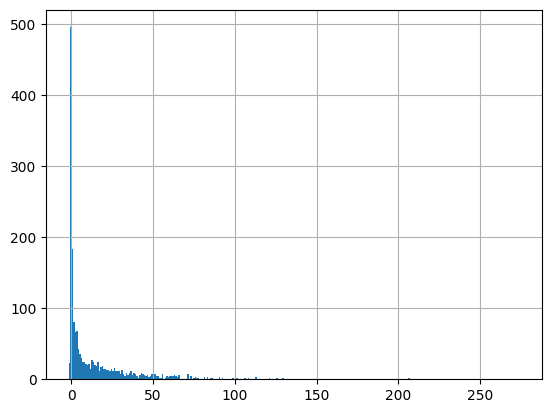

In [40]:
df['ADVANCED_WS'].hist(bins=300)

In [3]:
pip install scikit-learn statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 23.0 MB/s  0:00:0022.6 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 31.3 MB/s  0:00:00.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [statsmodels] 4/5 [statsmodels]]
Note: you may need to restart the kernel to use updated packages.
